## Deteccion de las variales presentes en nuestra base de datos

In [6]:
import pandas as pd
df_train = pd.read_csv('00-train.csv')

print(df_train.columns.tolist())

['Class', 'MIC_GOWAWA[0.6;1;S-OWA;1.0;0.0;2;W-OWA;0.9;1.0]_H_cdch', 'TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1.0]_T_cdch', 'TS[1]_SIC_T_scm', 'GV[4]_CHOQUET[A;-0.75;AO1;0.9]_H_pah', 'GV[1]_HM_H_pah', 'TS[3]_CHOQUET[A;-0.75;AO2;0.0]_N_scm', 'TS[4]_V_U_z3', 'TS[1]_CHOQUET[D;-0.75;AO1;1.0]_C_pie', 'GV[2]_CHOQUET[A;-0.75;AO1;0.3]_H_eps', 'GV[2]_GOWAWA[0.2;2;ES2-OWA;0.9;0.0;2;W-OWA;0.4;0.6]_N_pie', 'AC[7]_HM_U_mw', 'GV[2]_GOWAWA[0.8;1;AO2-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_U_eps', 'GV[3]_CHOQUET[A;-0.75;AO1;0.3]_H_pah', 'TS[4]_GOWAWA[0.7;1;AO2-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_N_scv', 'GV[3]_GOWAWA[0.1;0;W-OWA;0.1;0.6;2;W-OWA;0.1;0.2]_U_pie', 'GV[2]_CHOQUET[A;-0.75;AO1;0.2]_U_pbs', 'ES_SD_H_z2', 'AC[1]_CHOQUET[A;-0.75;AO1;0.2]_H_pah', 'CHOQUET[A;-0.75;AO1;0.9]_U_pbs', 'AC[1]_CHOQUET[A;0.5;AO2;0.5]_F_z3', 'AC[4]_AM_T_hwhh', 'AC[3]_CHOQUET[A;-0.75;AO1;0.3]_H_pah', 'GV[2]_GOWAWA[0.9;1;S-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_U_pah', 'TS[2]_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1.0]_U_isa', 'GV[4]_GOWAWA[

sudo: a terminal is required to read the password; either use the -S option to read from standard input or configure an askpass helper
sudo: a password is required


# Informacion Mutua

Variable objetivo identificada correctamente: 'Class'
Cantidad de características a evaluar: 95
Cantidad de registros de entrenamiento: 198

--- Calculando Información Mutua ---

 Top 10 características más informativas:
                                      Característica  Score_MI
0                                     TS[3]_Q1_T_eps  0.304955
1  TS[4]_GOWAWA[0.2;2;S-OWA;0.6;0.0;2;S-OWA;0.8;0...  0.302331
2                                     TS[2]_Q1_T_eps  0.288448
3                                       TS[4]_V_U_z3  0.285102
4                     CHOQUET[A;-0.75;AO1;1.0]_F_khh  0.279753
5                                      TS[3]_AM_F_z1  0.274131
6                      CHOQUET[A;-0.5;AO2;0.0]_N_isa  0.274077
7               GV[2]_CHOQUET[A;-0.75;AO1;0.3]_H_pah  0.269680
8  TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0....  0.267903
9               TS[3]_CHOQUET[A;-0.75;AO2;0.0]_N_scm  0.267876

--- Analizando Redundancia por Correlación ---

Variables altamente correlacionadas a

/tmp/ipykernel_1204773/3253466196.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score_MI', y='Característica', data=mi_df.head(12), palette='coolwarm')



 Gráfica 'filtro_informacion_mutua.png' guardada con éxito.


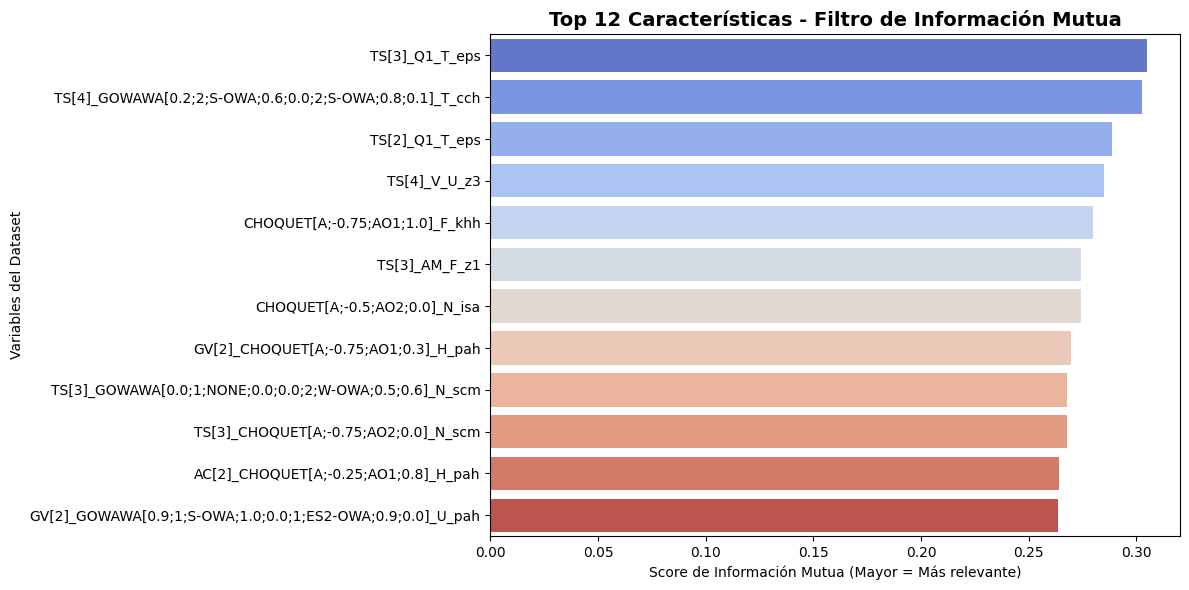

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

df_train = pd.read_csv('00-train.csv')

target_col = 'Class'

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

print(f"Variable objetivo identificada correctamente: '{target_col}'")
print(f"Cantidad de características a evaluar: {X_train.shape[1]}")
print(f"Cantidad de registros de entrenamiento: {X_train.shape[0]}")

print("\n--- Calculando Información Mutua ---")

# random_state=42 
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)


mi_df = pd.DataFrame({'Característica': X_train.columns, 'Score_MI': mi_scores})
mi_df = mi_df.sort_values(by='Score_MI', ascending=False).reset_index(drop=True)

print("\n Top 10 características más informativas:")
print(mi_df.head(10))

# Para seleccionar las 10 mejores para el subconjunto final
n_features_to_select = 10
features_mi_selected = mi_df['Característica'].head(n_features_to_select).tolist()



print("\n--- Analizando Redundancia por Correlación ---")


corr_matrix = X_train.corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Umbral de tolerancia a la redundancia (0.85)
threshold = 0.85
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

print(f"\nVariables altamente correlacionadas a eliminar (> {threshold}):")
if to_drop:
    print(to_drop)
else:
    print("Ninguna variable es críticamente redundante.")

features_corr_selected = [col for col in X_train.columns if col not in to_drop]


print("\n--- Resumen ---")
coincidencias = set(features_mi_selected).intersection(set(features_corr_selected))
print(f"• Variables seleccionadas por Info. Mutua: {len(features_mi_selected)}")
print(f"• Variables que pasaron el filtro de Correlación: {len(features_corr_selected)}")
print(f"• Variables idénticas en ambos métodos: {len(coincidencias)}")

plt.figure(figsize=(12, 6))
# Graficamos solo el top 12 
sns.barplot(x='Score_MI', y='Característica', data=mi_df.head(12), palette='coolwarm')
plt.title('Top 12 Características - Filtro de Información Mutua', fontsize=14, fontweight='bold')
plt.xlabel('Score de Información Mutua (Mayor = Más relevante)')
plt.ylabel('Variables del Dataset')
plt.tight_layout()

plt.savefig('filtro_informacion_mutua.png', dpi=300)
print("\n Gráfica 'filtro_informacion_mutua.png' guardada con éxito.")

# Correlacion Mutua


[RESULTADO] Se encontraron 18 variables altamente redundantes (r > 0.85):
  1. GV[2]_CHOQUET[A;-0.75;AO1;0.2]_U_pbs
  2. AC[1]_CHOQUET[A;-0.75;AO1;0.2]_H_pah
  3. AC[3]_CHOQUET[A;-0.75;AO1;0.3]_H_pah
  4. GV[2]_GOWAWA[0.9;1;S-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_U_pah
  5. AC[2]_CHOQUET[A;-0.5;AO1;0.2]_U_pbs
  6. AC[1]_HM_H_pah
  7. CHOQUET[D;-0.75;AO1;0.9]_B_isa
  8. TS[3]_HM_U_khh
  9. AC[7]_P2_T_z3
  10. GV[2]_CHOQUET[A;-0.75;AO1;0.3]_H_pah
  11. TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0.6]_N_scm
  12. SIC_T_scm
  13. TS[3]_GOWAWA[0.2;1;AO2-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_F_cch
  14. AC[2]_GOWAWA[0.9;1;S-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_B_pbs
  15. AC[2]_CHOQUET[A;-0.25;AO1;0.8]_H_pah
  16. TS[3]_Q1_T_eps
  17. CHOQUET[A;-0.5;AO2;0.0]_N_isa
  18. GOWAWA[0.8;1;AO2-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_F_mw

Dimensiones después del filtro de correlación: (198, 77)

 Gráfica guardada con éxito como: 'matriz_correlacion_heatmap.png'


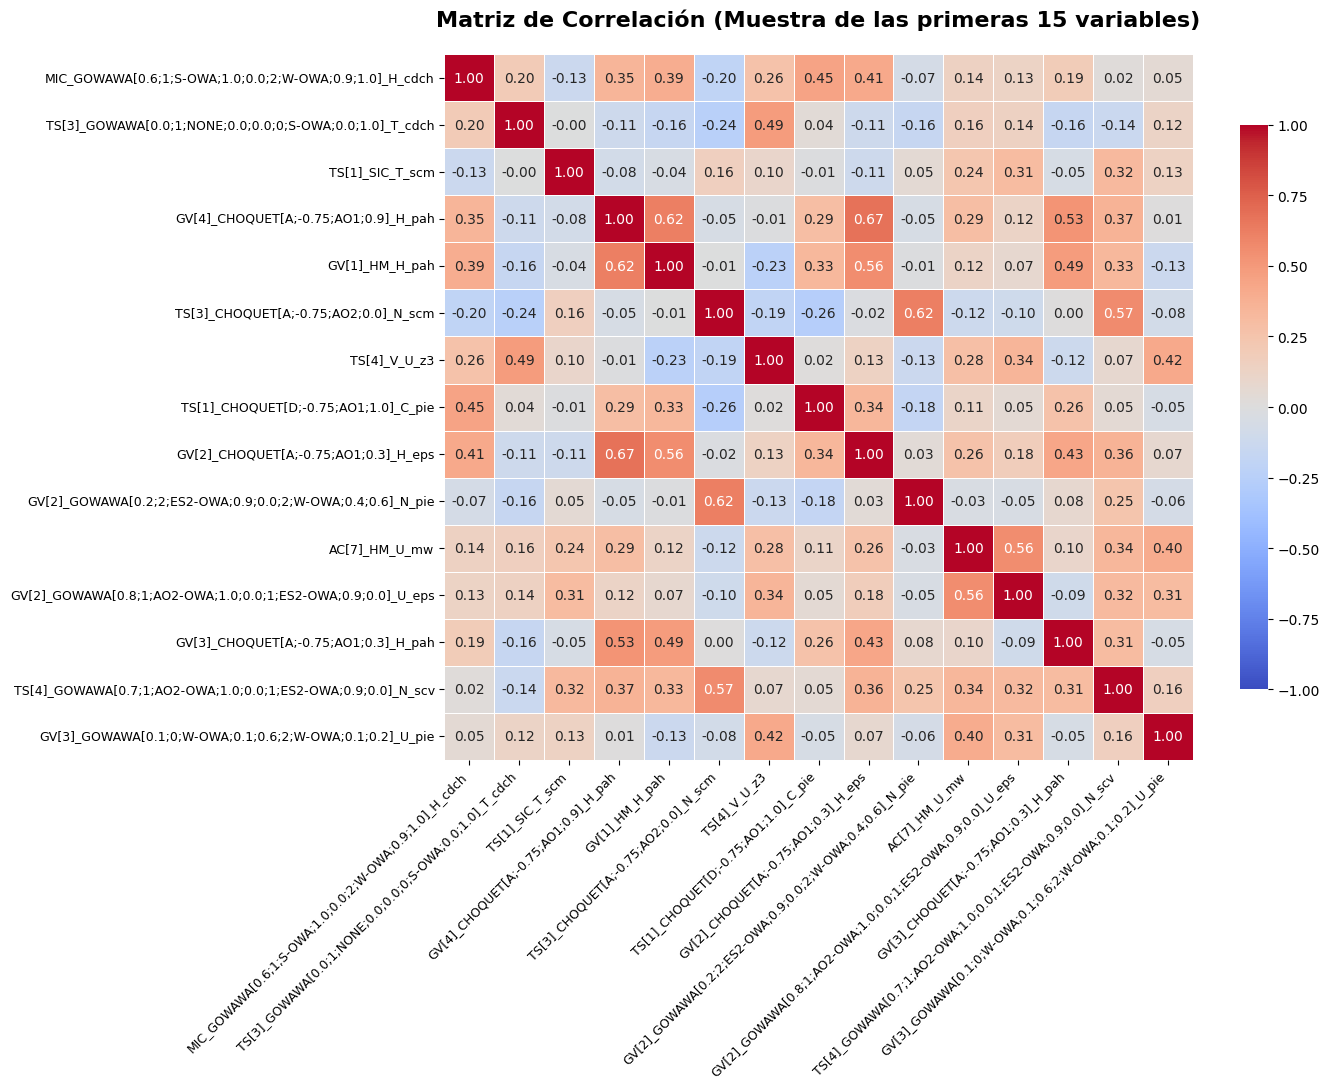

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_train = pd.read_csv('00-train.csv')
target_col = 'Class'

X_train = df_train.drop(columns=[target_col])


# Usamos Pearson por defecto. 
corr_matrix = X_train.corr(method='pearson')

# Se extrae solo la mitad superior de la matriz para no duplicar la evaluación (A vs B es lo mismo que B vs A)
upper_tri = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Definimos un umbral estricto de correlación (0.85)
threshold = 0.85

# Se biusca qué columnas superan ese umbral en alguna de sus celdas
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

print(f"\n[RESULTADO] Se encontraron {len(to_drop)} variables altamente redundantes (r > {threshold}):")
if to_drop:
    for idx, col in enumerate(to_drop, 1):
        print(f"  {idx}. {col}")
else:
    print("  ¡Ninguna variable supera el umbral! Todas aportan información limpia.")

# Crear el nuevo subconjunto de datos filtrado
X_train_filtered = X_train.drop(columns=to_drop)
print(f"\nDimensiones después del filtro de correlación: {X_train_filtered.shape}")


# seleccionamos un bloque representativo (ej. las primeras 15)
top_n_vis = 15
cols_to_plot = corr_matrix.columns[:top_n_vis]
sub_corr_matrix = corr_matrix.loc[cols_to_plot, cols_to_plot]

plt.figure(figsize=(14, 11))

# Creamos el mapa de calor con una paleta divergente (Coolwarm: azul=negativo, rojo=positivo)
sns.heatmap(
    sub_corr_matrix, 
    annot=True,              
    fmt=".2f",               
    cmap='coolwarm',         
    vmin=-1, vmax=1,         
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
)

plt.title(f'Matriz de Correlación (Muestra de las primeras {top_n_vis} variables)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()


output_img = 'matriz_correlacion_heatmap.png'
plt.savefig(output_img, dpi=300, bbox_inches='tight')
print(f"\n Gráfica guardada con éxito como: '{output_img}'")

# Wrapper



In [14]:
import pandas as pd
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier


df_train = pd.read_csv('00-train.csv')
target_col = 'Class'

X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]


# max_depth=5 
estimador_base = DecisionTreeClassifier(max_depth=5, random_state=42)


sfs = SequentialFeatureSelector(
    estimator=estimador_base,
    n_features_to_select=10,
    direction='forward',
    scoring='accuracy',
    cv=3, 
    n_jobs=-1 
)

print("\nEntrenando SFS")

# ENTRENAMIENTO Y SELECCIÓN
sfs.fit(X_train, y_train)

# EXTRACCIÓN DE RESULTADOS
features_sfs_selected = X_train.columns[sfs.get_support()].tolist()

print("\n==================================================")
print(" RESULTADOS DEL MÉTODO WRAPPER (SFS)")
print("==================================================")
print(f"Se seleccionaron las siguientes {len(features_sfs_selected)} variables:")
for idx, col in enumerate(features_sfs_selected, 1):
    print(f"  {idx}. {col}")

X_train_sfs = X_train[features_sfs_selected]
print(f"\nDimensiones del nuevo set de entrenamiento: {X_train_sfs.shape}")


Entrenando SFS

 RESULTADOS DEL MÉTODO WRAPPER (SFS)
Se seleccionaron las siguientes 10 variables:
  1. GV[2]_GOWAWA[0.2;2;ES2-OWA;0.9;0.0;2;W-OWA;0.4;0.6]_N_pie
  2. AC[7]_HM_U_mw
  3. TS[4]_GOWAWA[0.7;1;AO2-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_N_scv
  4. GV[3]_GOWAWA[0.1;0;W-OWA;0.1;0.6;2;W-OWA;0.1;0.2]_U_pie
  5. TS[2]_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1.0]_U_isa
  6. GV[1]_P2_U_pbs
  7. GV[3]_GOWAWA[0.4;1;AO2-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_U_scv
  8. TS[4]_GOWAWA[0.2;2;S-OWA;0.6;0.0;2;S-OWA;0.8;0.1]_T_cch
  9. AC[1]_AM_T_kh
  10. TS[3]_Q1_T_eps

Dimensiones del nuevo set de entrenamiento: (198, 10)


In [16]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


RUTA_BASE = './'
train_df = pd.read_csv(os.path.join(RUTA_BASE, '00-train.csv'))
tuning_df = pd.read_csv(os.path.join(RUTA_BASE, '01-tuning.csv'))
external_df = pd.read_csv(os.path.join(RUTA_BASE, '02-external.csv'))

target_col = 'Class'


X_train = train_df.drop(target_col, axis=1)
y_train = train_df[target_col]



scaler = StandardScaler()

# Se entrena el escalador SOLO con X_train para evitar Data Leakage
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# Tuning y External
X_tuning_orig = tuning_df.drop(columns=[target_col]) if target_col in tuning_df.columns else tuning_df
X_tuning_scaled = pd.DataFrame(scaler.transform(X_tuning_orig), columns=X_tuning_orig.columns)
y_tuning_orig = tuning_df[target_col] if target_col in tuning_df.columns else None

X_external_orig = external_df.drop(columns=[target_col]) if target_col in external_df.columns else external_df
X_external_scaled = pd.DataFrame(scaler.transform(X_external_orig), columns=X_external_orig.columns)
y_external_orig = external_df[target_col] if target_col in external_df.columns else None


def calculate_subset_merit(X_subset, y):
    """Calcula el Mérito del Subconjunto basado en Correlación (CFS) de forma segura."""
    k = X_subset.shape[1]
    if k == 0: return 0
    
    
    le = LabelEncoder()
    y_num = le.fit_transform(y)
        
    X_num = X_subset.astype(float)
    
    
    # r_cf: Correlación promedio clase-característica
    corrs_with_target = []
    for col in X_num.columns:
        corr = np.abs(np.corrcoef(X_num[col].values, y_num)[0, 1])
        corrs_with_target.append(corr)
    
    r_cf = np.mean(corrs_with_target)
    
    # r_ff: Correlación promedio característica-característica
    corr_matrix = X_num.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    r_ff = upper_tri.mean().mean()
    
    if pd.isna(r_ff): r_ff = 0
    
    # Mérito (Fórmula CFS)
    merit = (k * r_cf) / np.sqrt(k + k * (k - 1) * r_ff)
    return merit

def wrapper_feature_selection(X, y, model, search_method='forward', k_features=10, cv=5, scoring='accuracy', n_jobs=-1):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    estimator = clone(model)
    selector = SequentialFeatureSelector(estimator=estimator, n_features_to_select=k_features, direction=search_method, scoring=scoring, cv=kf, n_jobs=n_jobs)
    selector.fit(X, y)
    return X.columns[selector.get_support()]

modelos = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

merit_scores = {}

for mod_name, model in modelos.items():
    print(f"\n" + "="*60)
    print(f"Wrapper (SFS) para: {mod_name}")
    print("="*60)
    
    # SELECCIÓN EXCLUSIVAMENTE CON TRAIN
    selected_features_names = wrapper_feature_selection(
        X=X_train_scaled, y=y_train, model=model, k_features=10
    )
    
    # CÁLCULO DE MÉTRICA DE SUBCONJUNTO
    merit = calculate_subset_merit(X_train_scaled[selected_features_names], y_train)
    merit_scores[mod_name] = merit
    
    print(f"▶ Características seleccionadas:\n{selected_features_names.tolist()}")
    print(f"▶ Mérito del Subconjunto (CFS): {merit:.4f}\n")

    
    pd.concat([X_train_scaled[selected_features_names], y_train.reset_index(drop=True)], axis=1).to_csv(os.path.join(RUTA_BASE, f'train_selected_{mod_name}.csv'), index=False)
    
    X_tuning_selected = X_tuning_scaled[selected_features_names]
    (pd.concat([X_tuning_selected, y_tuning_orig.reset_index(drop=True)], axis=1) if y_tuning_orig is not None else X_tuning_selected).to_csv(os.path.join(RUTA_BASE, f'tuning_selected_{mod_name}.csv'), index=False)
    
    X_external_selected = X_external_scaled[selected_features_names]
    (pd.concat([X_external_selected, y_external_orig.reset_index(drop=True)], axis=1) if y_external_orig is not None else X_external_selected).to_csv(os.path.join(RUTA_BASE, f'external_selected_{mod_name}.csv'), index=False)


print("\n" + "#"*80)
print("REPORTE DE DISCUSIÓN Y ESTABILIDAD")
print("#"*80)
print(f" COMPARACIÓN DE SUBCONJUNTOS (Correlation Subset Merit):")
for mod, score in merit_scores.items():
    print(f"   - {mod}: {score:.4f}")
mejor_modelo = max(merit_scores, key=merit_scores.get)
print(f"\nEl subconjunto seleccionado por {mejor_modelo} obtuvo el mayor mérito. Esto indica que dicho subconjunto tiene la mejor relación de alta correlación predictiva hacia la variable 'Class' y baja redundancia entre sus variables internas.")



Wrapper (SFS) para: LogisticRegression
▶ Características seleccionadas:
['TS[3]_CHOQUET[A;-0.75;AO2;0.0]_N_scm', 'GV[2]_GOWAWA[0.2;2;ES2-OWA;0.9;0.0;2;W-OWA;0.4;0.6]_N_pie', 'GV[3]_GOWAWA[0.1;0;W-OWA;0.1;0.6;2;W-OWA;0.1;0.2]_U_pie', 'ES_SD_H_z2', 'AC[4]_AM_T_hwhh', 'GV[2]_GOWAWA[0.9;1;S-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_U_pah', 'GV[4]_GOWAWA[0.2;2;ES2-OWA;0.9;0.0;2;W-OWA;0.4;0.6]_T_eps', 'TS[4]_GOWAWA[0.5;1;AO2-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_F_cch', 'TS[3]_HM_U_khh', 'TS[2]_CHOQUET[A;-0.25;AO2;1.0]_T_khh']
▶ Mérito del Subconjunto (CFS): 0.4441


Wrapper (SFS) para: SVM
▶ Características seleccionadas:
['GV[3]_AM_U_z2', 'CHOQUET[D;-0.25;AO1;0.8]_B_scv', 'TS[2]_SIC_T_cch', 'TS[3]_HM_U_khh', 'GV[7]_P2_T_z3', 'AC[7]_P2_T_z3', 'TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1.0]_T_pah', 'AC[3]_N3_U_hwhh', 'TS[4]_GOWAWA[0.2;2;S-OWA;0.6;0.0;2;S-OWA;0.8;0.1]_T_cch', 'TS[3]_Q1_T_eps']
▶ Mérito del Subconjunto (CFS): 0.5988


Wrapper (SFS) para: kNN
▶ Características seleccionadas:
['GV[4]_CHOQUET[A

# Modelos base

In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings

warnings.filterwarnings('ignore')

train_df = pd.read_csv('train_selected_RandomForest.csv')
tuning_df = pd.read_csv('tuning_selected_RandomForest.csv')

target_col = 'Class'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_tuning = tuning_df.drop(columns=[target_col])
y_tuning = tuning_df[target_col]


le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_tuning_num = le.transform(y_tuning)


modelos = {
    'Regresión Logística': LogisticRegression(random_state=42),
    'SVM (Lineal)': SVC(kernel='linear', probability=True, random_state=42),
    'k-NN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42)
}


resultados = []


for nombre, modelo in modelos.items():
    
    modelo.fit(X_train, y_train_num)
    
    
    y_pred = modelo.predict(X_tuning)
    y_prob = modelo.predict_proba(X_tuning)
    
    
    is_multiclass = len(le.classes_) > 2
    avg_method = 'macro' if is_multiclass else 'binary'
    
    # Cálculo de métricas
    acc = accuracy_score(y_tuning_num, y_pred)
    prec = precision_score(y_tuning_num, y_pred, average=avg_method)
    rec = recall_score(y_tuning_num, y_pred, average=avg_method)
    f1 = f1_score(y_tuning_num, y_pred, average=avg_method)
    
    
    if is_multiclass:
        roc = roc_auc_score(y_tuning_num, y_prob, multi_class='ovo')
    else:
        roc = roc_auc_score(y_tuning_num, y_prob[:, 1])
        
    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc
    })


df_resultados = pd.DataFrame(resultados).set_index('Modelo')

print("="*80)
print(" COMPARACIÓN DE MODELOS BASE (Métricas sobre Tuning Set)")
print("="*80)
print(df_resultados.round(4).to_string())
print("="*80)

 COMPARACIÓN DE MODELOS BASE (Métricas sobre Tuning Set)
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                             
Regresión Logística    0.7581     0.7353  0.8065    0.7692   0.9022
SVM (Lineal)           0.7903     0.7500  0.8710    0.8060   0.9043
k-NN                   0.8387     0.8182  0.8710    0.8438   0.8746
Random Forest          0.8548     0.8667  0.8387    0.8525   0.9412


# Hiperparametros

In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import f1_score, accuracy_score
import warnings

warnings.filterwarnings('ignore')


train_df = pd.read_csv('train_selected_RandomForest.csv')
tuning_df = pd.read_csv('tuning_selected_RandomForest.csv')

target_col = 'Class'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_tuning = tuning_df.drop(columns=[target_col])
y_tuning = tuning_df[target_col]


le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_tuning_num = le.transform(y_tuning)


X_combined = pd.concat([X_train, X_tuning], axis=0).reset_index(drop=True)
y_combined = np.concatenate([y_train_num, y_tuning_num])


split_index = [-1] * len(X_train) + [0] * len(X_tuning)
pds = PredefinedSplit(test_fold=split_index)


is_multiclass = len(le.classes_) > 2
scoring_metric = 'f1_macro' if is_multiclass else 'f1'



param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

param_dist_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

# Espacio de búsqueda para Regresión Logística
param_dist_lr = {
    'C': [0.01, 0.1, 1, 10, 100],          # Inverso de la fuerza de regularización
    'penalty': ['l1', 'l2'],               # Tipo de penalización
    'solver': ['liblinear', 'saga']       
}

# Espacio de búsqueda para k-NN
param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],   
    'weights': ['uniform', 'distance'],    
    'p': [1, 2]                            
}


# --- OPTIMIZACIÓN RANDOM FOREST ---

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=15, 
    cv=pds,    
    scoring=scoring_metric,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_combined, y_combined)

# --- OPTIMIZACIÓN SVM ---
svm_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_distributions=param_dist_svm,
    n_iter=15, 
    cv=pds,    
    scoring=scoring_metric,
    random_state=42,
    n_jobs=-1
)
svm_search.fit(X_combined, y_combined)

# --- OPTIMIZACIÓN REGRESIÓN LOGÍSTICA ---
lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_distributions=param_dist_lr,
    n_iter=15, 
    cv=pds,    
    scoring=scoring_metric,
    random_state=42,
    n_jobs=-1
)
lr_search.fit(X_combined, y_combined)

# --- OPTIMIZACIÓN k-NN ---
knn_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=15, 
    cv=pds,    
    scoring=scoring_metric,
    random_state=42,
    n_jobs=-1
)
knn_search.fit(X_combined, y_combined)

print("\n" + "="*60)
print("HIPERPARÁMETROS SELECCIONADOS")
print("="*60)

print(f"▶ RANDOM FOREST:")
print(f"   Mejores Parámetros: {rf_search.best_params_}")
print(f"   F1-Score en Tuning : {rf_search.best_score_:.4f}\n")

print(f"▶ SVM:")
print(f"   Mejores Parámetros: {svm_search.best_params_}")
print(f"   F1-Score en Tuning : {svm_search.best_score_:.4f}\n")

print(f"▶ REGRESIÓN LOGÍSTICA:")
print(f"   Mejores Parámetros: {lr_search.best_params_}")
print(f"   F1-Score en Tuning : {lr_search.best_score_:.4f}\n")

print(f"▶ k-NN:")
print(f"   Mejores Parámetros: {knn_search.best_params_}")
print(f"   F1-Score en Tuning : {knn_search.best_score_:.4f}")
print("="*60)


HIPERPARÁMETROS SELECCIONADOS
▶ RANDOM FOREST:
   Mejores Parámetros: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'criterion': 'entropy'}
   F1-Score en Tuning : 0.8710

▶ SVM:
   Mejores Parámetros: {'kernel': 'rbf', 'gamma': 0.01, 'C': 100}
   F1-Score en Tuning : 0.8182

▶ REGRESIÓN LOGÍSTICA:
   Mejores Parámetros: {'solver': 'saga', 'penalty': 'l1', 'C': 0.1}
   F1-Score en Tuning : 0.8125

▶ k-NN:
   Mejores Parámetros: {'weights': 'distance', 'p': 1, 'n_neighbors': 5}
   F1-Score en Tuning : 0.8571


# Analisis de diversidad

In [20]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')


train_df = pd.read_csv('train_selected_RandomForest.csv')
tuning_df = pd.read_csv('tuning_selected_RandomForest.csv')

target_col = 'Class'
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_tuning = tuning_df.drop(columns=[target_col])
y_tuning = tuning_df[target_col]

le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_tuning_num = le.transform(y_tuning)


modelos = {
    'Regresión Logística': LogisticRegression(
        C=0.1, 
        penalty='l1', 
        solver='saga', 
        random_state=42
    ),
    'SVM': SVC(
        C=100, 
        gamma=0.01, 
        kernel='rbf', 
        random_state=42
    ),
    'k-NN': KNeighborsClassifier(
        n_neighbors=5, 
        p=1, 
        weights='distance'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        min_samples_split=2, 
        min_samples_leaf=2, 
        max_depth=None, 
        criterion='entropy', 
        random_state=42
    )
}

# Diccionario para almacenar las predicciones de cada modelo en Tuning
preds = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train_num)
    preds[nombre] = modelo.predict(X_tuning)



pares = list(combinations(modelos.keys(), 2))
N = len(y_tuning_num)

resultados_diversidad = []

for mod1, mod2 in pares:
    pred1 = preds[mod1]
    pred2 = preds[mod2]
    
    
    n11 = np.sum((pred1 == y_tuning_num) & (pred2 == y_tuning_num))
    n10 = np.sum((pred1 == y_tuning_num) & (pred2 != y_tuning_num))
    n01 = np.sum((pred1 != y_tuning_num) & (pred2 == y_tuning_num))
    n00 = np.sum((pred1 != y_tuning_num) & (pred2 != y_tuning_num)) 
    
    
    desacuerdo = (n10 + n01) / N
    
    
    doble_fallo = n00 / N
    
    resultados_diversidad.append({
        'Modelo A': mod1,
        'Modelo B': mod2,
        'Desacuerdo ↑': desacuerdo,
        'Doble Fallo ↓': doble_fallo
    })


df_diversidad = pd.DataFrame(resultados_diversidad)

print("\n" + "="*70)
print(" MATRIZ DE DIVERSIDAD ENTRE MODELOS OPTIMIZADOS (Sobre Tuning Set)")
print("="*70)
print(df_diversidad.to_string(index=False))
print("="*70)


 MATRIZ DE DIVERSIDAD ENTRE MODELOS OPTIMIZADOS (Sobre Tuning Set)
           Modelo A      Modelo B  Desacuerdo ↑  Doble Fallo ↓
Regresión Logística           SVM      0.064516       0.161290
Regresión Logística          k-NN      0.145161       0.096774
Regresión Logística Random Forest      0.096774       0.112903
                SVM          k-NN      0.080645       0.129032
                SVM Random Forest      0.129032       0.096774
               k-NN Random Forest      0.048387       0.112903


In [21]:
!pip install xgboost

# Modelos por ensamble

In [22]:
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')

train_df = pd.read_csv('train_selected_RandomForest.csv')
tuning_df = pd.read_csv('tuning_selected_RandomForest.csv')

target_col = 'Class'
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_tuning = tuning_df.drop(columns=[target_col])
y_tuning = tuning_df[target_col]

# --- ¡FIX DE XGBOOST! ---
X_train.columns = X_train.columns.str.replace(r'[\[\]<]', '_', regex=True)
X_tuning.columns = X_tuning.columns.str.replace(r'[\[\]<]', '_', regex=True)
# -----------------------------------


le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_tuning_num = le.transform(y_tuning)


is_multiclass = len(le.classes_) > 2
avg_method = 'macro' if is_multiclass else 'binary'


rf_base = RandomForestClassifier(n_estimators=100, min_samples_split=2, min_samples_leaf=2, max_depth=None, criterion='entropy', random_state=42)
knn_base = KNeighborsClassifier(n_neighbors=5, p=1, weights='distance') 
svm_base = SVC(C=100, gamma=0.01, kernel='rbf', probability=True, random_state=42)


modelos_ensemble = {
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    
    'XGBoost': XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        eval_metric='mlogloss' if is_multiclass else 'logloss', 
        random_state=42
    ),
    
    'Ensamble Manual (Votación Soft)': VotingClassifier(
        estimators=[
            ('rf', rf_base),
            ('knn', knn_base),
            ('svm', svm_base)
        ],
        voting='soft' 
    )
}


resultados_ensemble = []



for nombre, modelo in modelos_ensemble.items():
    # Entrenamiento exclusivo con Train
    modelo.fit(X_train, y_train_num)
    
    # Predicciones en Tuning
    y_pred = modelo.predict(X_tuning)
    y_prob = modelo.predict_proba(X_tuning)
    
    # Métricas
    acc = accuracy_score(y_tuning_num, y_pred)
    prec = precision_score(y_tuning_num, y_pred, average=avg_method)
    rec = recall_score(y_tuning_num, y_pred, average=avg_method)
    f1 = f1_score(y_tuning_num, y_pred, average=avg_method)
    
    if is_multiclass:
        roc = roc_auc_score(y_tuning_num, y_prob, multi_class='ovo')
    else:
        roc = roc_auc_score(y_tuning_num, y_prob[:, 1])
        
    resultados_ensemble.append({
        'Modelo Ensemble': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc
    })


df_ensemble_res = pd.DataFrame(resultados_ensemble).set_index('Modelo Ensemble')

print("="*85)
print(" RENDIMIENTO DE LOS MODELOS POR ENSEMBLE CONSTRUIDOS (Tuning Set)")
print("="*85)
print(df_ensemble_res.round(4).to_string())
print("="*85)

 RENDIMIENTO DE LOS MODELOS POR ENSEMBLE CONSTRUIDOS (Tuning Set)
                                 Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo Ensemble                                                                
AdaBoost                           0.9194     0.9062  0.9355    0.9206   0.9292
XGBoost                            0.8387     0.8621  0.8065    0.8333   0.9126
Ensamble Manual (Votación Soft)    0.8871     0.9000  0.8710    0.8852   0.9157
